# Explore here

## Step 1: Problem statement and data collection

Problem statement: Given a dataset from the National Institute of Diabetes and Digestive and Kidney Diseases, set up a decision tree to predict whether or not a patient has diabetes.

In [2]:
# Import dataset to start working with it
import pandas as pd

raw_data = pd.read_csv("../data/raw/diabetes.csv", sep=",")

## Step 2: Exploration and data cleaning

In [3]:
print(f"Raw data shape: {raw_data.shape}")
print(raw_data.info())

Raw data shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Unlike prior exercise, doesn't look as though any of our columns have missing data at all, which simplifies matters.

Will do a simple drop_duplicates. I don't see anything like an ID column to need to get fancier with.

In [4]:
raw_data.drop_duplicates(inplace=True)


print(raw_data.shape)
raw_data.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# remove data considered irrelevant...

# skipping the below because as of yet, none of the columns in the raw dataset look strictly-irrelevant to me

# raw_data.drop(
#    ["id", "name", "host_name", "last_review", "reviews_per_month"],
#    axis=1,
#    inplace=True,
# )



#raw_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 3: Analysis of univariate variables
### categorical variables
Categorical, non-numeric variables in this dataframe include: outcome. That's it.  The rest are numeric.

All of these are plausible to me as relevant.

In [7]:
categorical_variables = [
    "Outcome",
]

for each_categorical_variable in categorical_variables:
    print(f"\n\t{each_categorical_variable}s:")
    for each_possible_value in sorted(
        raw_data[f"{each_categorical_variable}"].unique()
    ):
        print(each_possible_value)


	Outcomes:
0
1


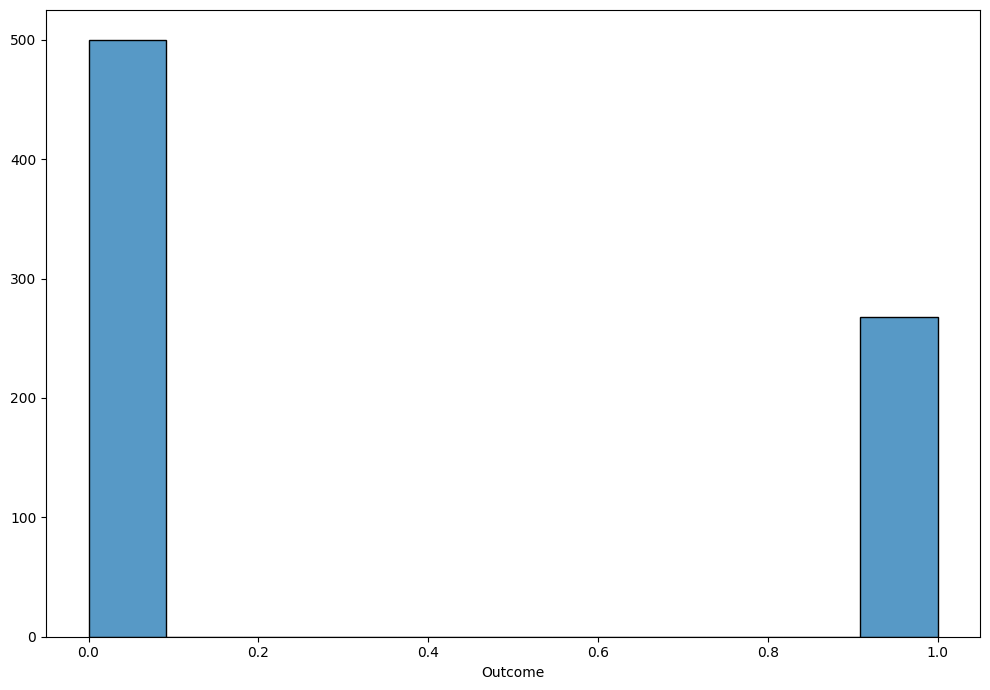

In [10]:
# histogram-plot each categorical variable

import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(1, 1, figsize=(10, 7))

# Create a multiple histogram
sns.histplot(data=raw_data, x="Outcome").set(ylabel=None)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

- Many more diabetics in the dataset than I would've guessed.

### numeric variables

Numerical, non-categorical variables in the dataset include: everything but Outcome

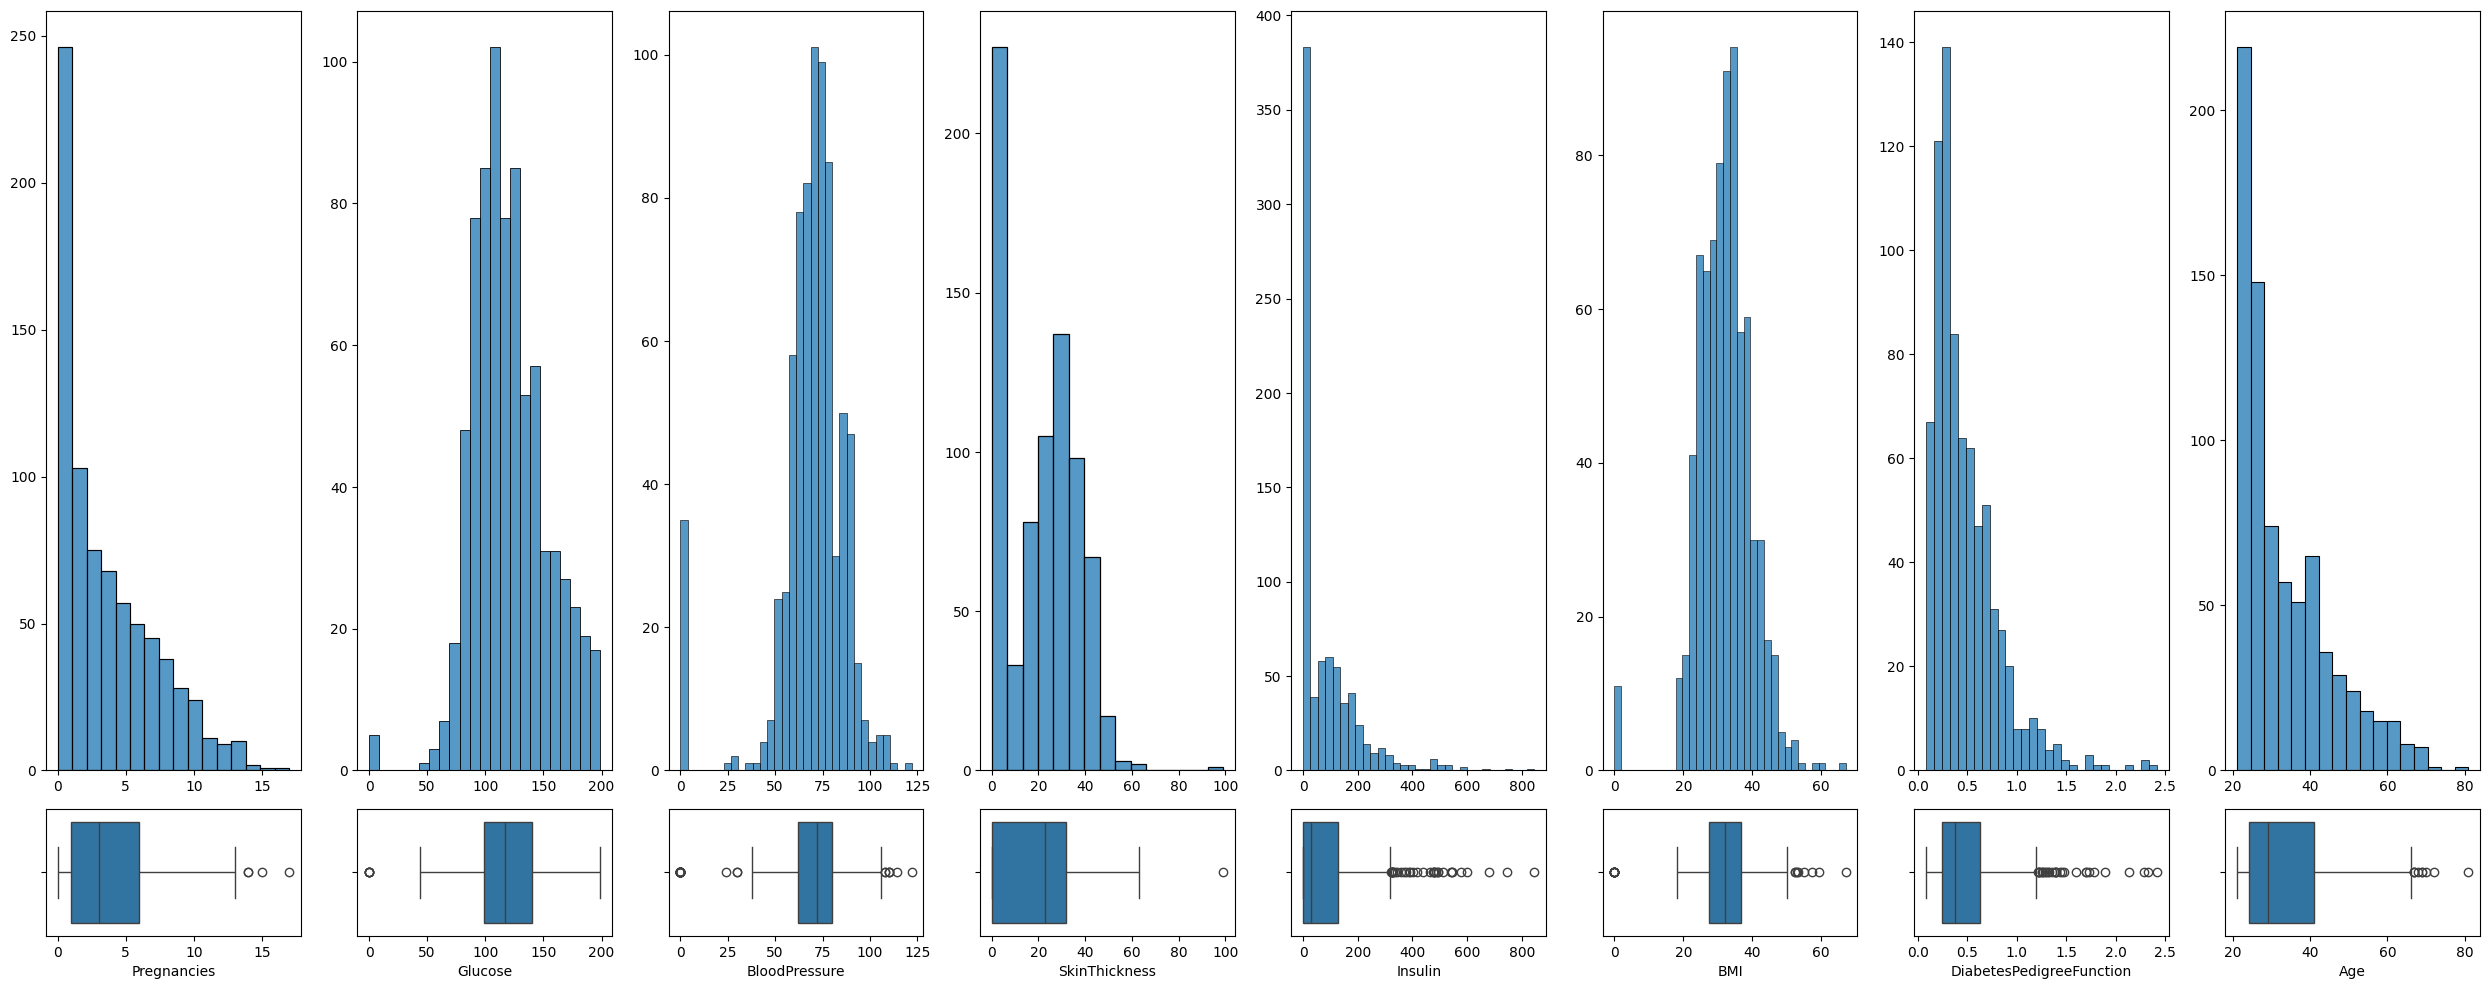

In [11]:
numeric_variables = raw_data.columns[~raw_data.columns.isin(categorical_variables)]

fig, axis = plt.subplots(
    2, len(numeric_variables), figsize=(25, 10), gridspec_kw={"height_ratios": [6, 1]}
)

# Creating a multiple figure with histograms and box plots
temp_column_index = 0
for each_numeric_variable in numeric_variables:
    sns.histplot(
        ax=axis[0, temp_column_index], data=raw_data, x=f"{each_numeric_variable}"
    ).set(xlabel=None, ylabel=None)
    sns.boxplot(
        ax=axis[1, temp_column_index], data=raw_data, x=f"{each_numeric_variable}"
    )
    temp_column_index += 1

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

From this it looks like:
- some women had upwards of a dozen pregnancies (!)
- Someone's runnning around out there with either no glucose in their system or got an invalid measurement of it
- Guessing the outliers like 0 BMI correspond to unknowns or mis-entered data.

## Step 4: Analysis of multivariate variables
### Numerical-numerical analysis
Am curious to see whether/how there are correlations between pregnancies and skin thickness vs. more intuitive correlations such as age.

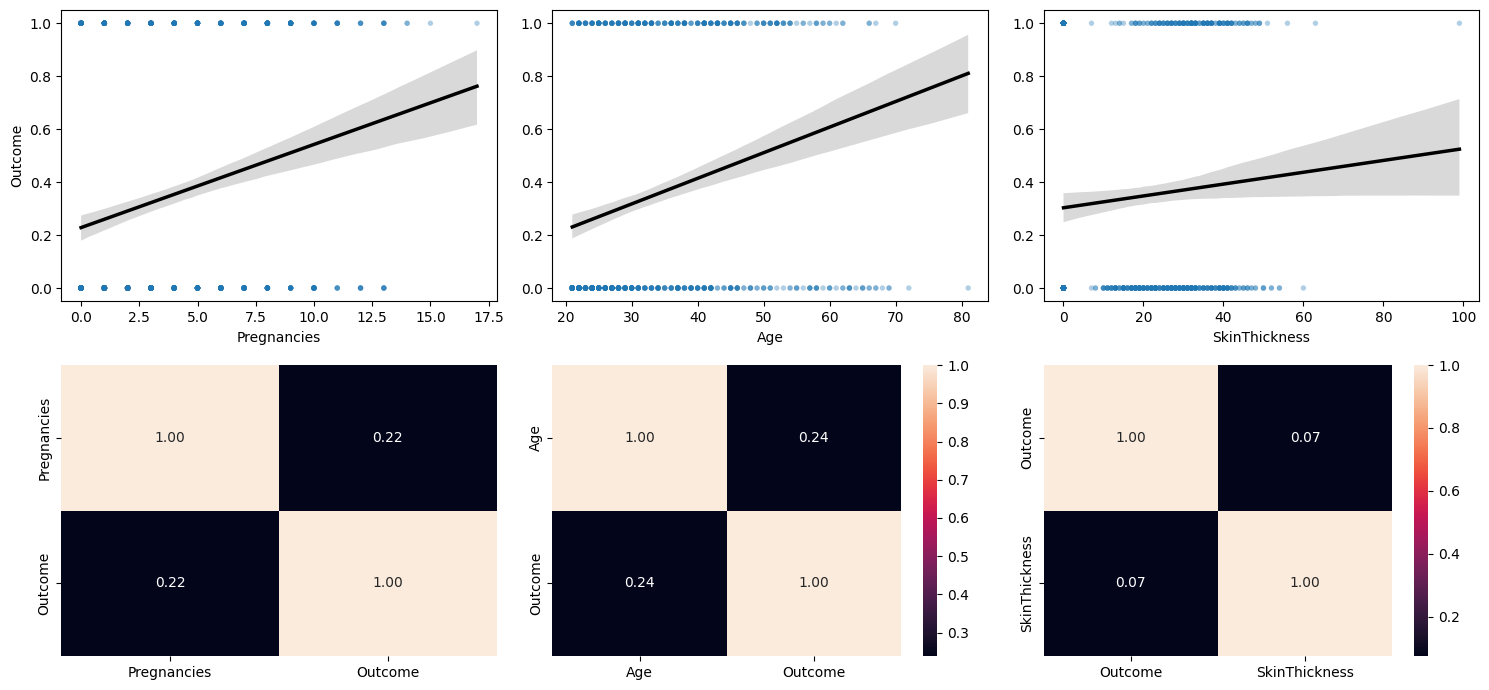

In [20]:
fig, axis = plt.subplots(2, 3, figsize=(15, 7))

# Create a multiple scatter diagram
common_scatter = {"s": 15, "alpha": 0.35, "edgecolor": "none"}
common_line = {"color": "black", "lw": 2.5, "zorder": 5}

sns.regplot(
    ax=axis[0, 0],
    data=raw_data,
    x="Pregnancies",
    y="Outcome",
    scatter_kws=common_scatter,
    line_kws=common_line,
)
sns.heatmap(
    raw_data[["Pregnancies", "Outcome"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 0],
    cbar=False,
)

sns.regplot(
    ax=axis[0, 1],
    data=raw_data,
    x="Age",
    y="Outcome",
    scatter_kws=common_scatter,
    line_kws=common_line,
).set(ylabel=None)
sns.heatmap(
    raw_data[["Age", "Outcome"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 1],
)

sns.regplot(
    ax=axis[0, 2],
    data=raw_data,
    x="SkinThickness",
    y="Outcome",
    scatter_kws=common_scatter,
    line_kws=common_line,
).set(ylabel=None)
sns.heatmap(
    raw_data[["Outcome", "SkinThickness"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 2],
)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

Increasing # of pregnancies, aging, or even choosing to age further away from here, all appear correlated to diabetes.

### categorical-categorical analysis

In [ ]:
# skipped because there's only one categorical feature to cover

######## skipped because there's only one categorical feature to cover

#### Correlation analysis


##### skipped; covered by heatmap in a cell not much further below

### numerical-categorical analysis

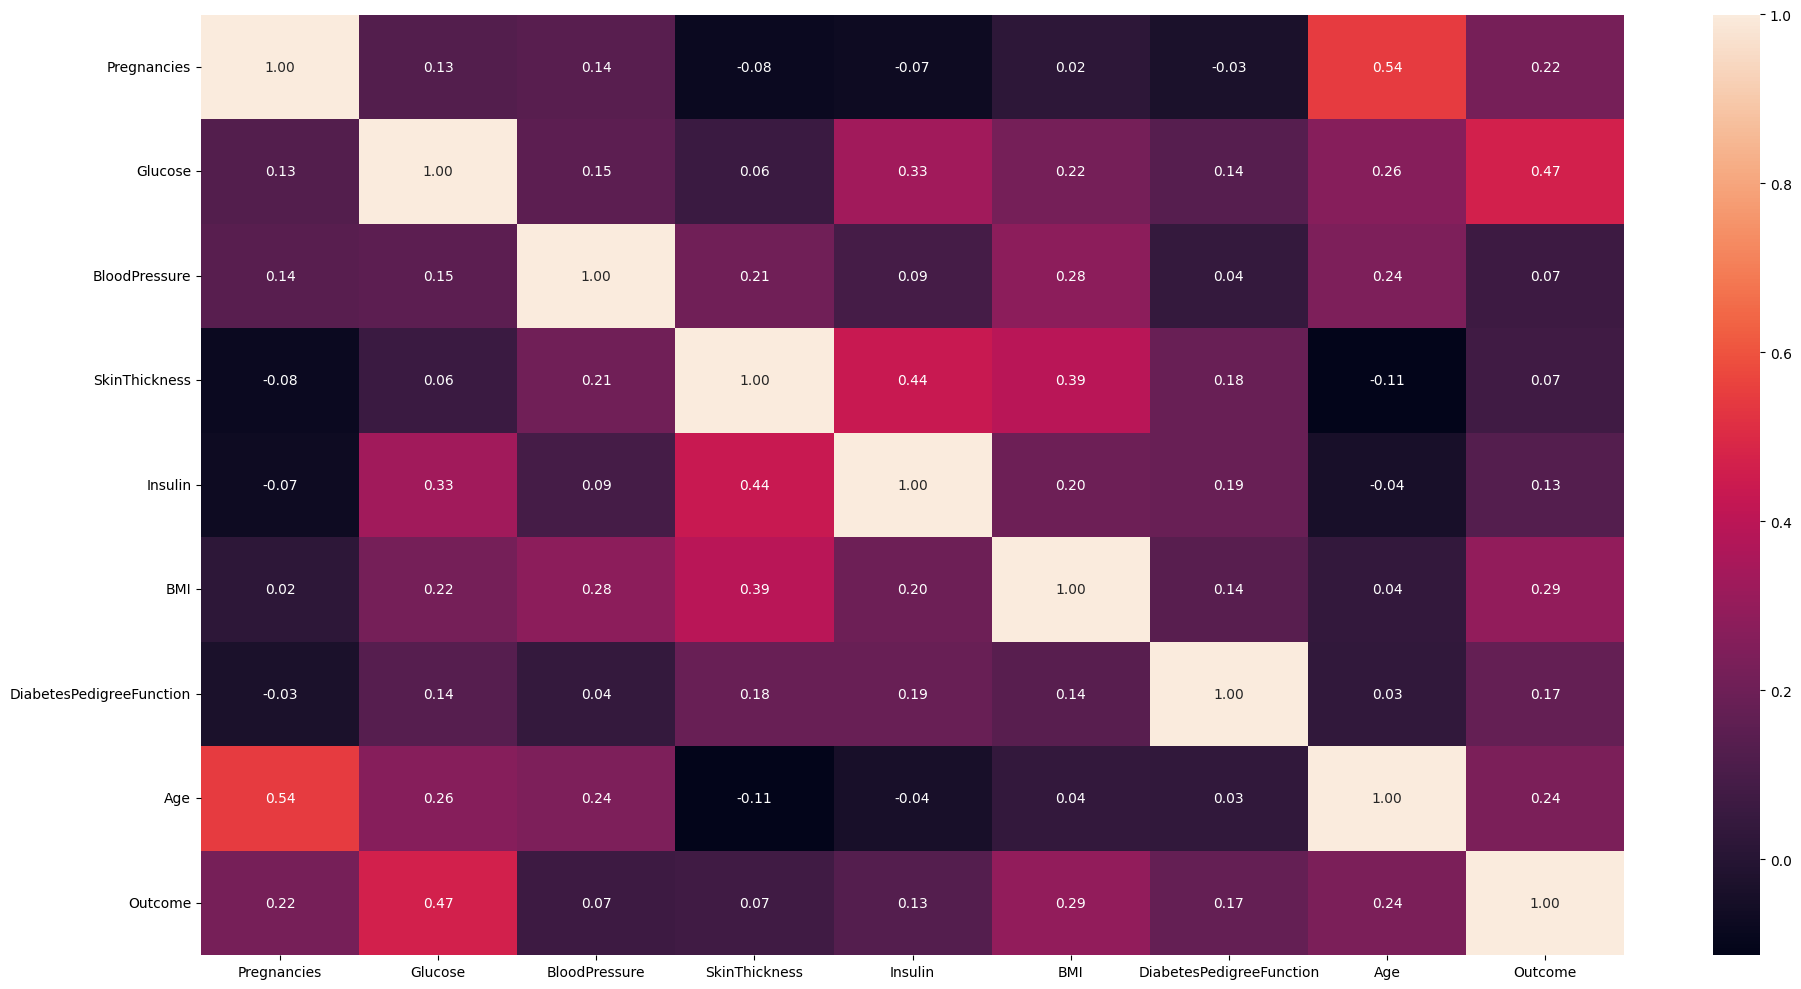

In [22]:
fig, axis = plt.subplots(figsize=(20, 10))

sns.heatmap(
    raw_data[list(raw_data.columns)].corr(),
    annot=True,
    fmt=".2f",
)

plt.tight_layout()

plt.show()

Based on the above, I'd assess the strongest correlations are between age and pregnancies, between glucose and outcome, and between insulin and skin thickness.

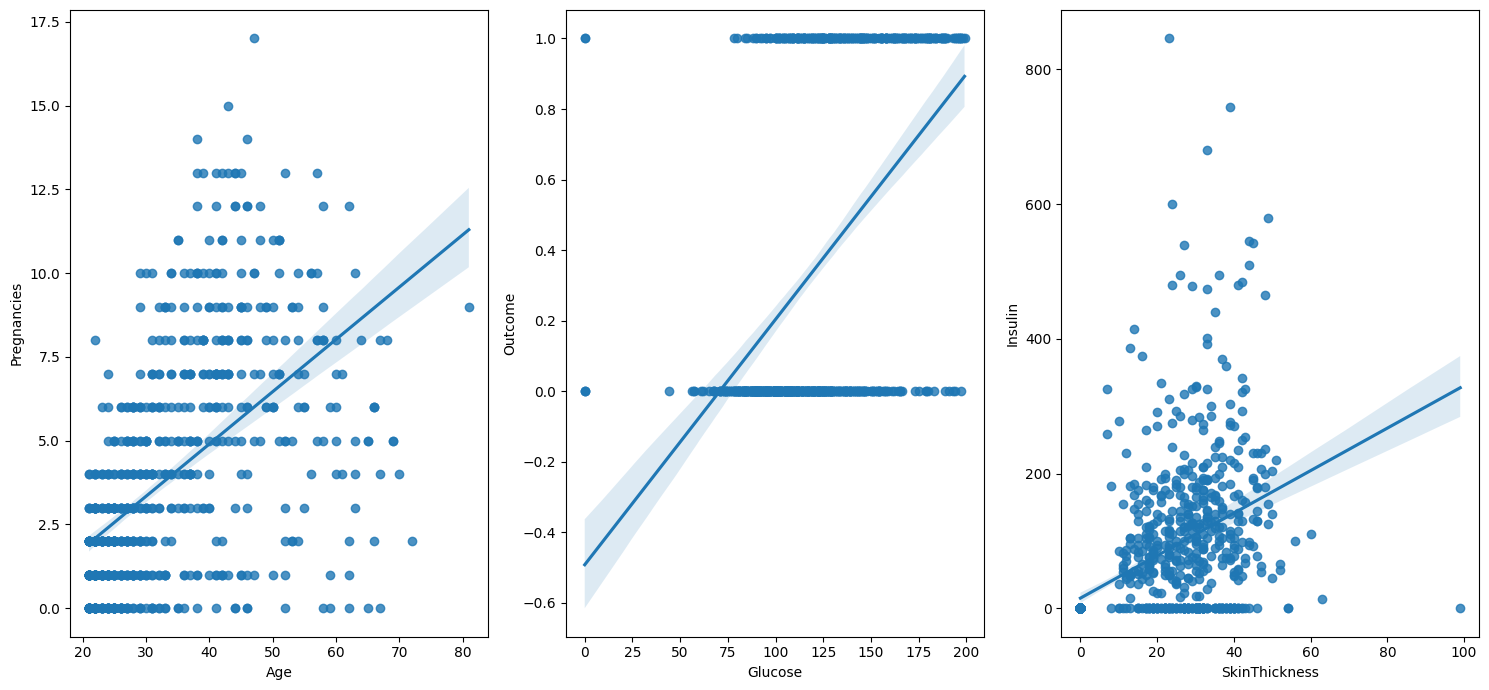

In [25]:
fig, axis = plt.subplots(figsize=(15, 7), ncols=3)

sns.regplot(ax=axis[0], data=raw_data, x="Age", y="Pregnancies")
sns.regplot(ax=axis[1], data=raw_data, x="Glucose", y="Outcome")
sns.regplot(ax=axis[2], data=raw_data, x="SkinThickness", y="Insulin")

plt.tight_layout()

plt.show()

Based on these regression plots:
- More likely to have had more pregnancies if you're an older person
- More likely to be diagnosed with diabetes if you have higher glucose levels
- More likely to have thicker skin if you have high insulin, or vice versa


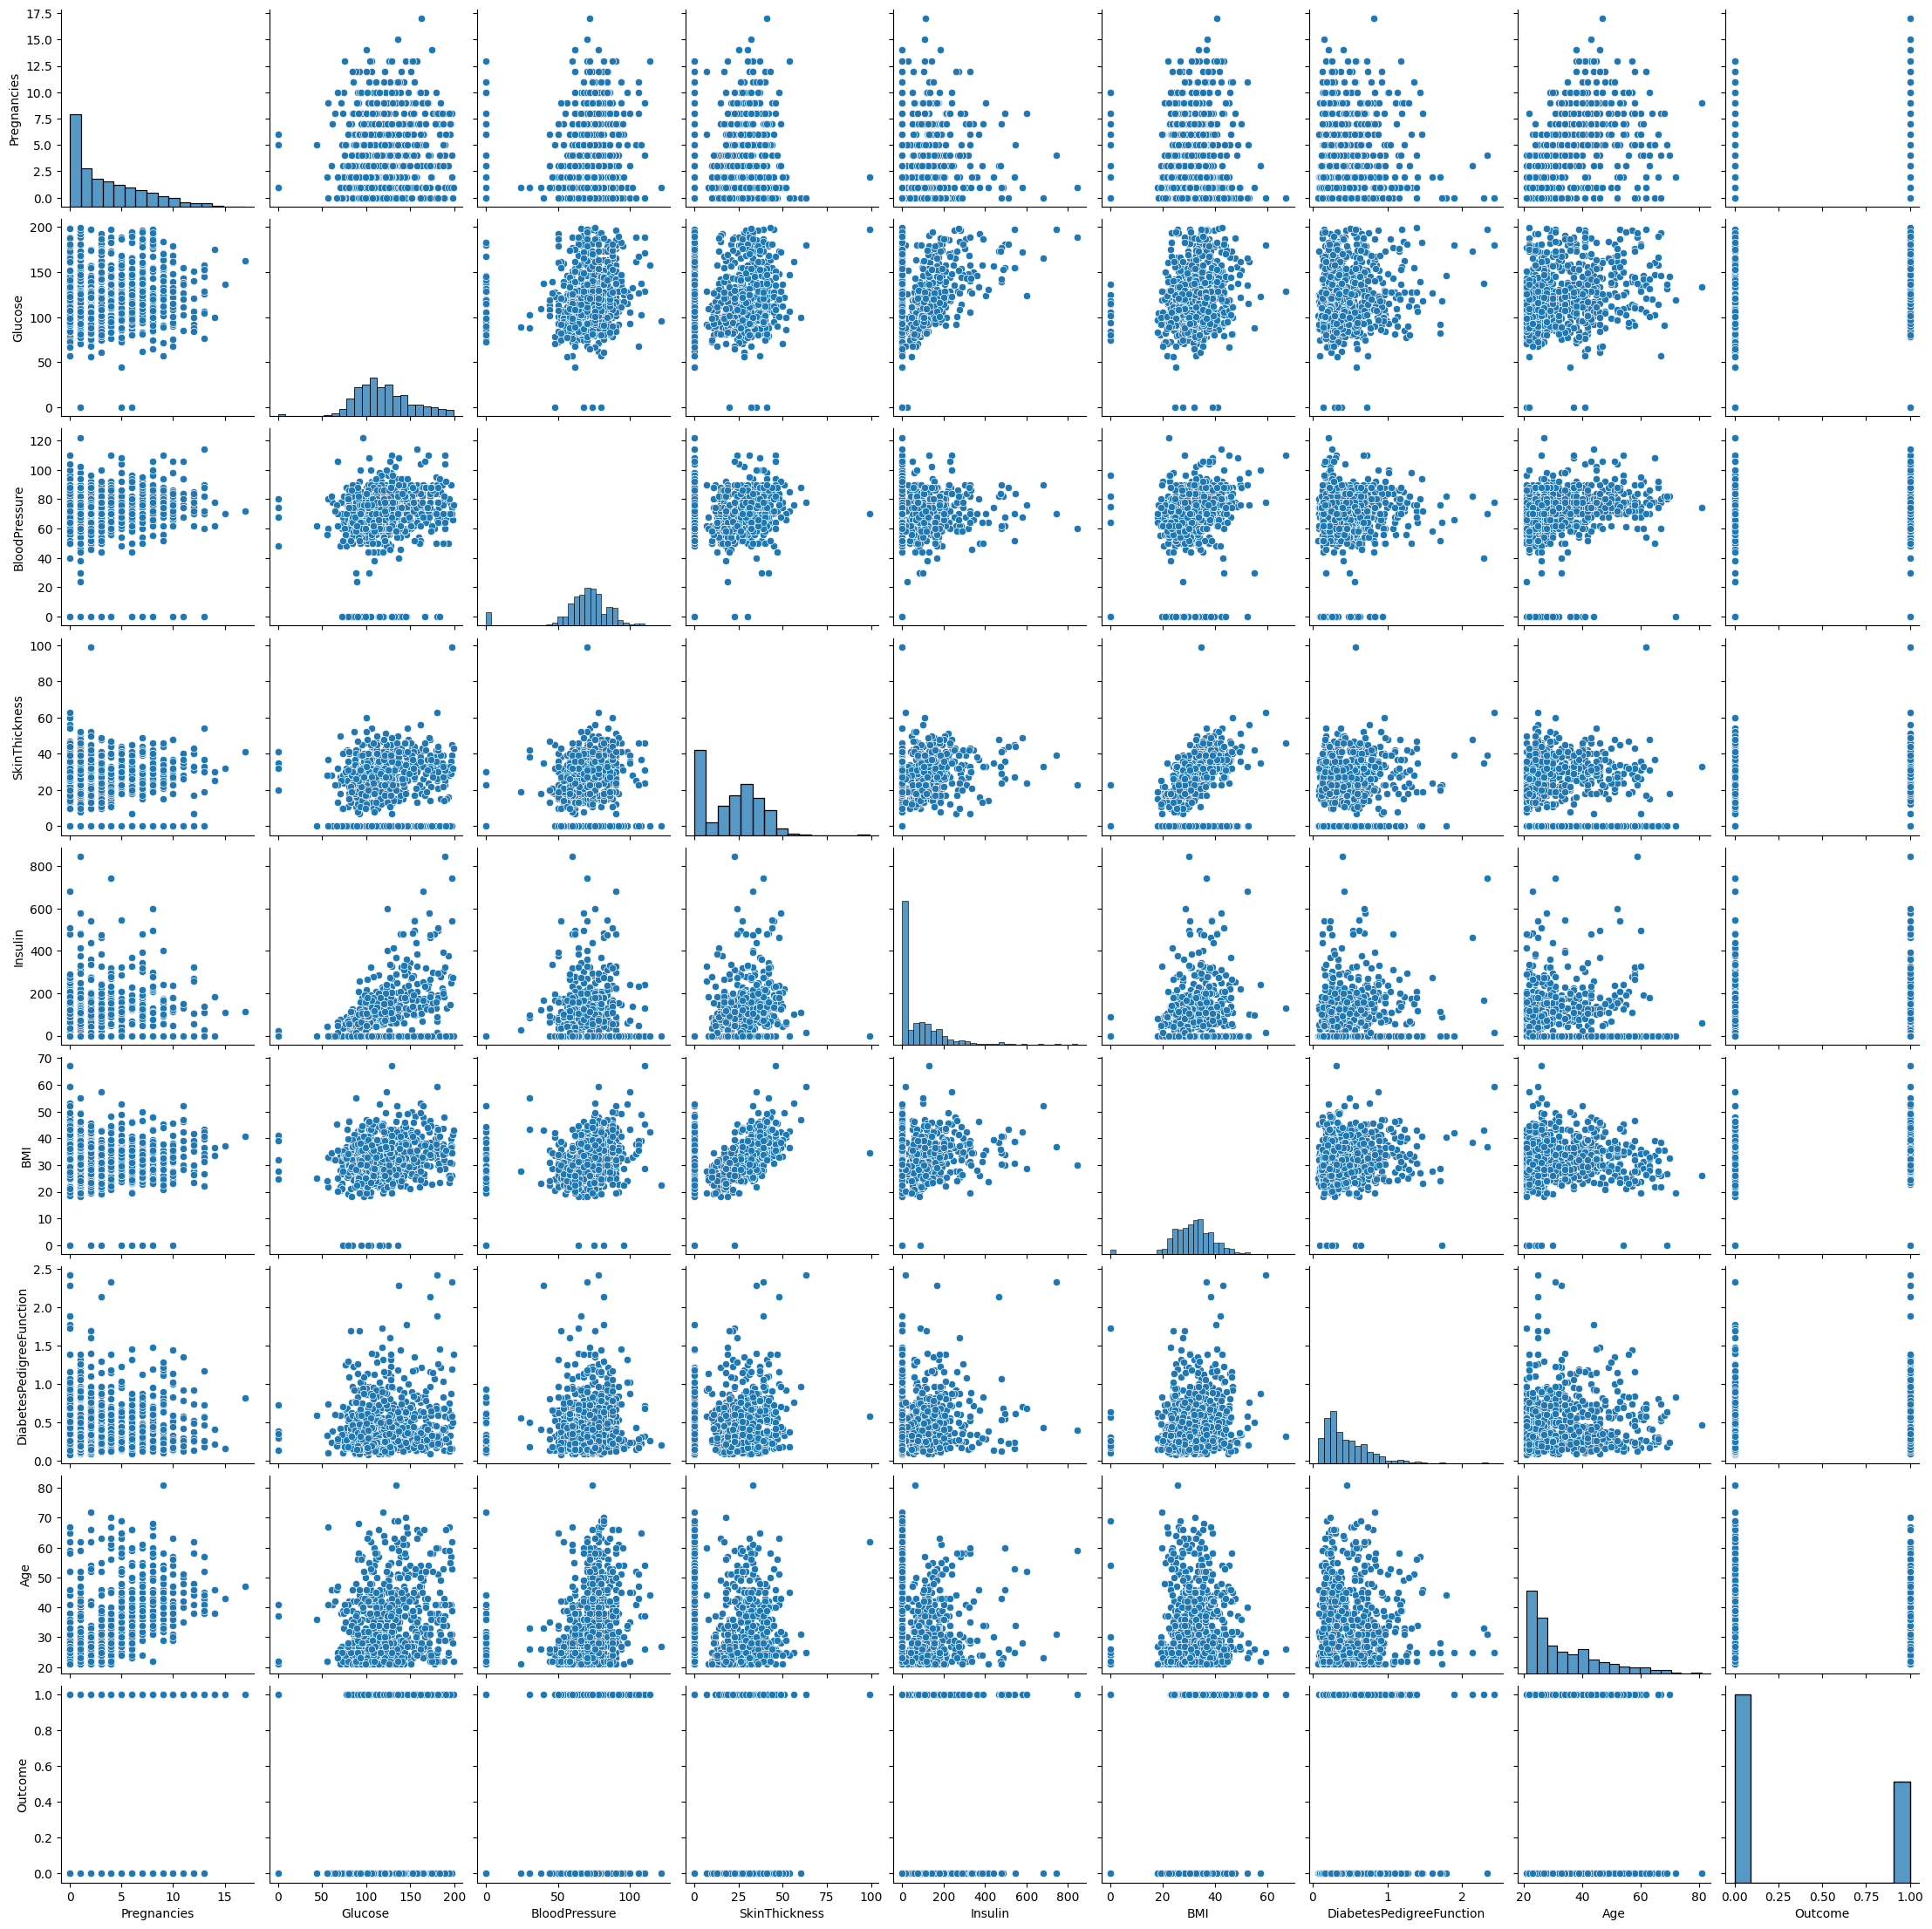

In [26]:
sns.pairplot(data=raw_data)

In [86]:
raw_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,3.673863,0.510637,3.277370,0.208908,0.571959,0.199825,0.634714,2.249951,1.979600,0.169953
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,2.454340,0.696794,2.185558,0.406713,0.541216,0.456055,0.481516,2.429157,1.411539,0.455811
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,3.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,2.000000,2.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,4.000000,1.000000,6.000000,0.000000,1.000000,0.000000,1.000000,3.000000,3.000000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,11.000000,3.000000,7.000000,2.000000,2.000000,2.000000,1.000000,9.000000,4.000000,2.000000


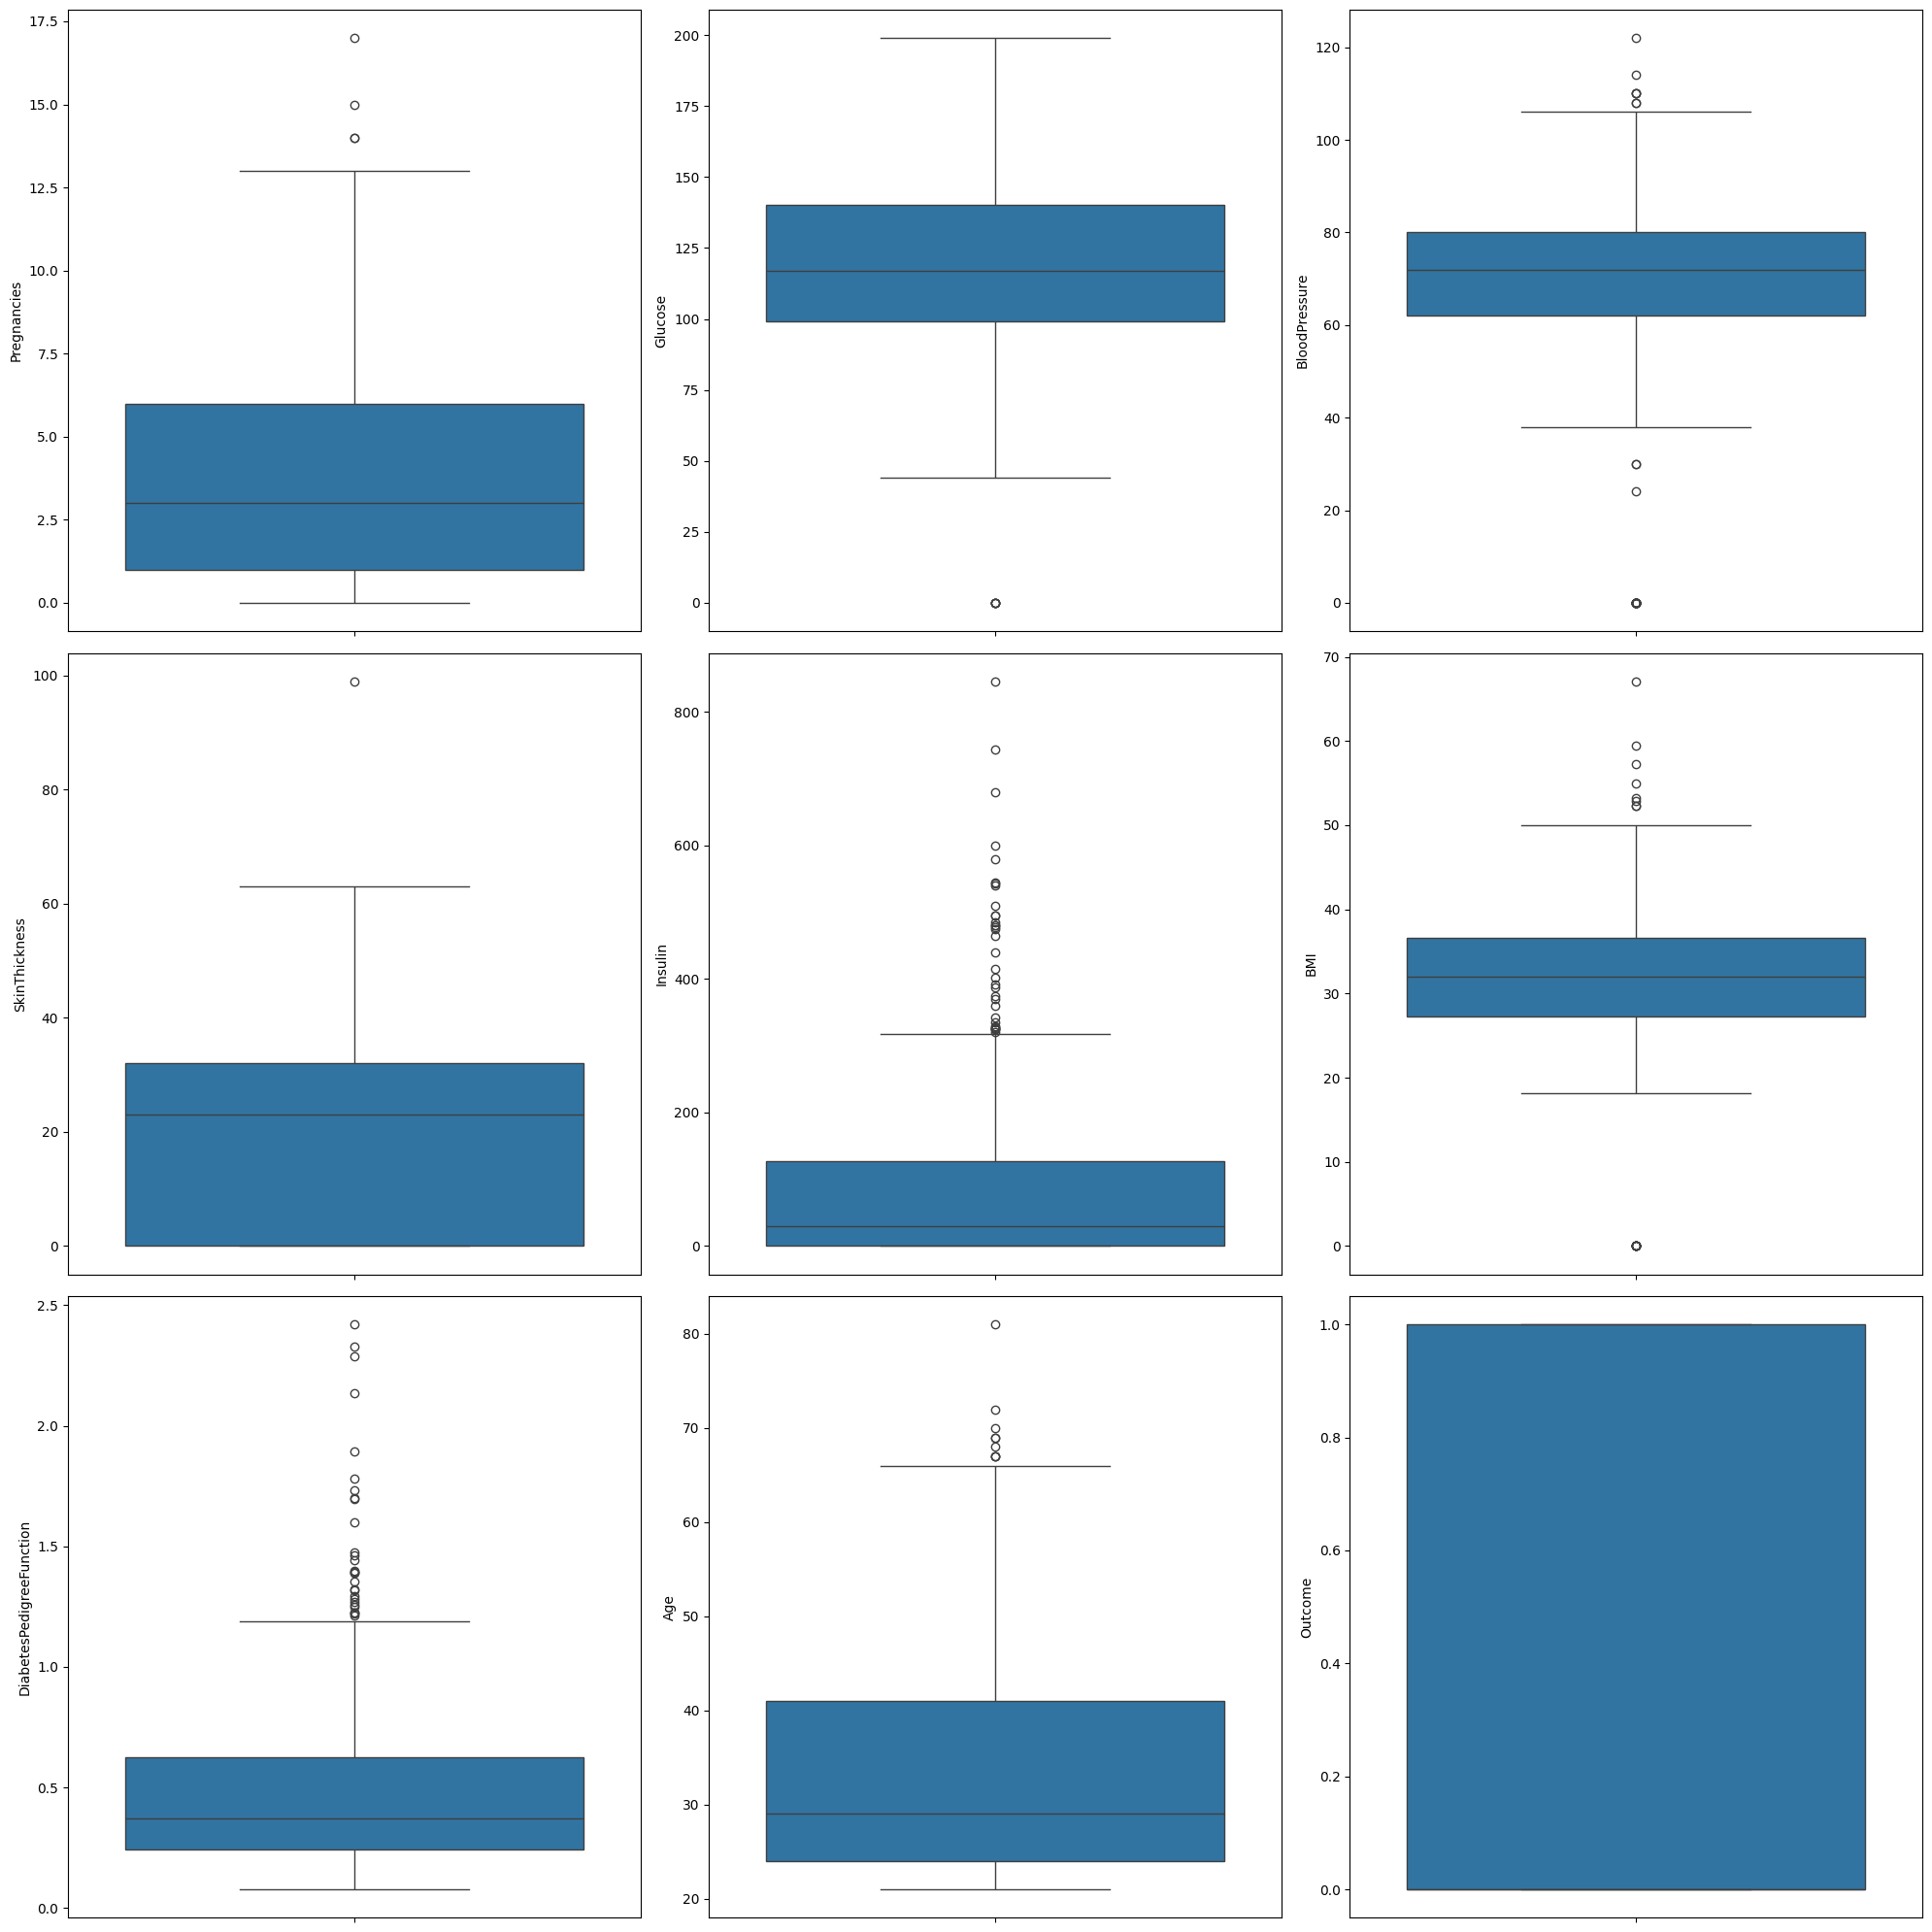

In [32]:
fig, axis = plt.subplots(3, 3, figsize=(20, 20))

sns.boxplot(ax=axis[0, 0], data=raw_data, y="Pregnancies")
sns.boxplot(ax=axis[0, 1], data=raw_data, y="Glucose")
sns.boxplot(ax=axis[0, 2], data=raw_data, y="BloodPressure")
sns.boxplot(ax=axis[1, 0], data=raw_data, y="SkinThickness")
sns.boxplot(ax=axis[1, 1], data=raw_data, y="Insulin")
sns.boxplot(ax=axis[1, 2], data=raw_data, y="BMI")
sns.boxplot(ax=axis[2, 0], data=raw_data, y="DiabetesPedigreeFunction")
sns.boxplot(ax=axis[2, 1], data=raw_data, y="Age")
sns.boxplot(ax=axis[2, 2], data=raw_data, y="Outcome")

plt.tight_layout()

plt.show()

Outcome variable appears not to have any outliers in need of finding and eliminating.


In [ ]:
## Step 1: Compute Q1 and Q3
#Q1 = raw_data["anycondition_prevalence"].quantile(0.25)
#Q3 = raw_data["anycondition_prevalence"].quantile(0.75)
#
## Step 2: Compute IQR
#IQR = Q3 - Q1
#
## Step 3: Determine bounds
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR
#
## Step 4: Filter out outliers
#df_filtered = raw_data[
#    (raw_data["anycondition_prevalence"] >= lower_bound)
#    & (raw_data["faanycondition_prevalencere"] <= upper_bound)
#]
#
#print("Original Data:")
#print(raw_data)
#print("\nFiltered Data (Outliers Removed):")
#print(df_filtered)


In [ ]:
#print(raw_data["cons.conf.idx"].describe())
#outlier_threshold = -30  # picked approximately 80th percentile
#atypical_cons_conf_idx = raw_data.query("`cons.conf.idx` > @outlier_threshold")
#print(atypical_cons_conf_idx)
#raw_data = raw_data.query(
#    f"`cons.conf.idx` <= {outlier_threshold}"
#)  # to drop the outlier rows

count    41176.000000
mean       -40.502863
std          4.627860
min        -50.800000
25%        -42.700000
50%        -41.800000
75%        -36.400000
max        -26.900000
Name: cons.conf.idx, dtype: float64
       age           job   marital          education  default housing loan  \
37887   53        admin.   married  university.degree  unknown     yes   no   
37888   32        admin.    single  university.degree       no     yes  yes   
37889   52        admin.   married            unknown       no      no   no   
37890   39  entrepreneur   married           basic.6y       no     yes   no   
37891   32        admin.    single  university.degree       no     yes   no   
...    ...           ...       ...                ...      ...     ...  ...   
38596   69       retired   married           basic.4y       no     yes  yes   
38597   18       student    single           basic.6y       no      no  yes   
38598   59       retired  divorced           basic.4y       no     yes   no  

### Building logistic regression model

#### Feature scaling
##### Splitting training vs test data

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True, as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2


<Axes: >

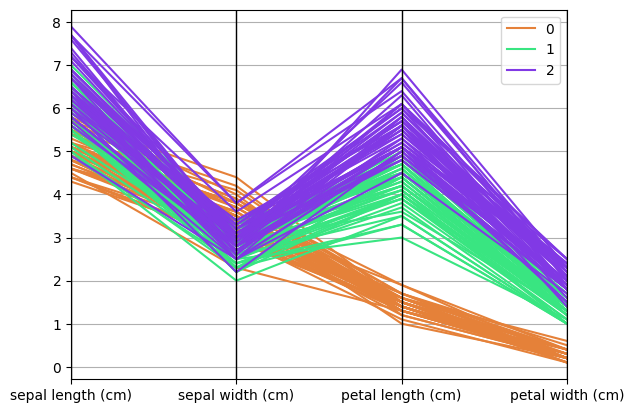

In [34]:
import pandas as pd

total_data = X
total_data["Outcome"] = y

pd.plotting.parallel_coordinates(
    total_data, "Outcome", color=("#E58139", "#39E581", "#8139E5")
)

In [35]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

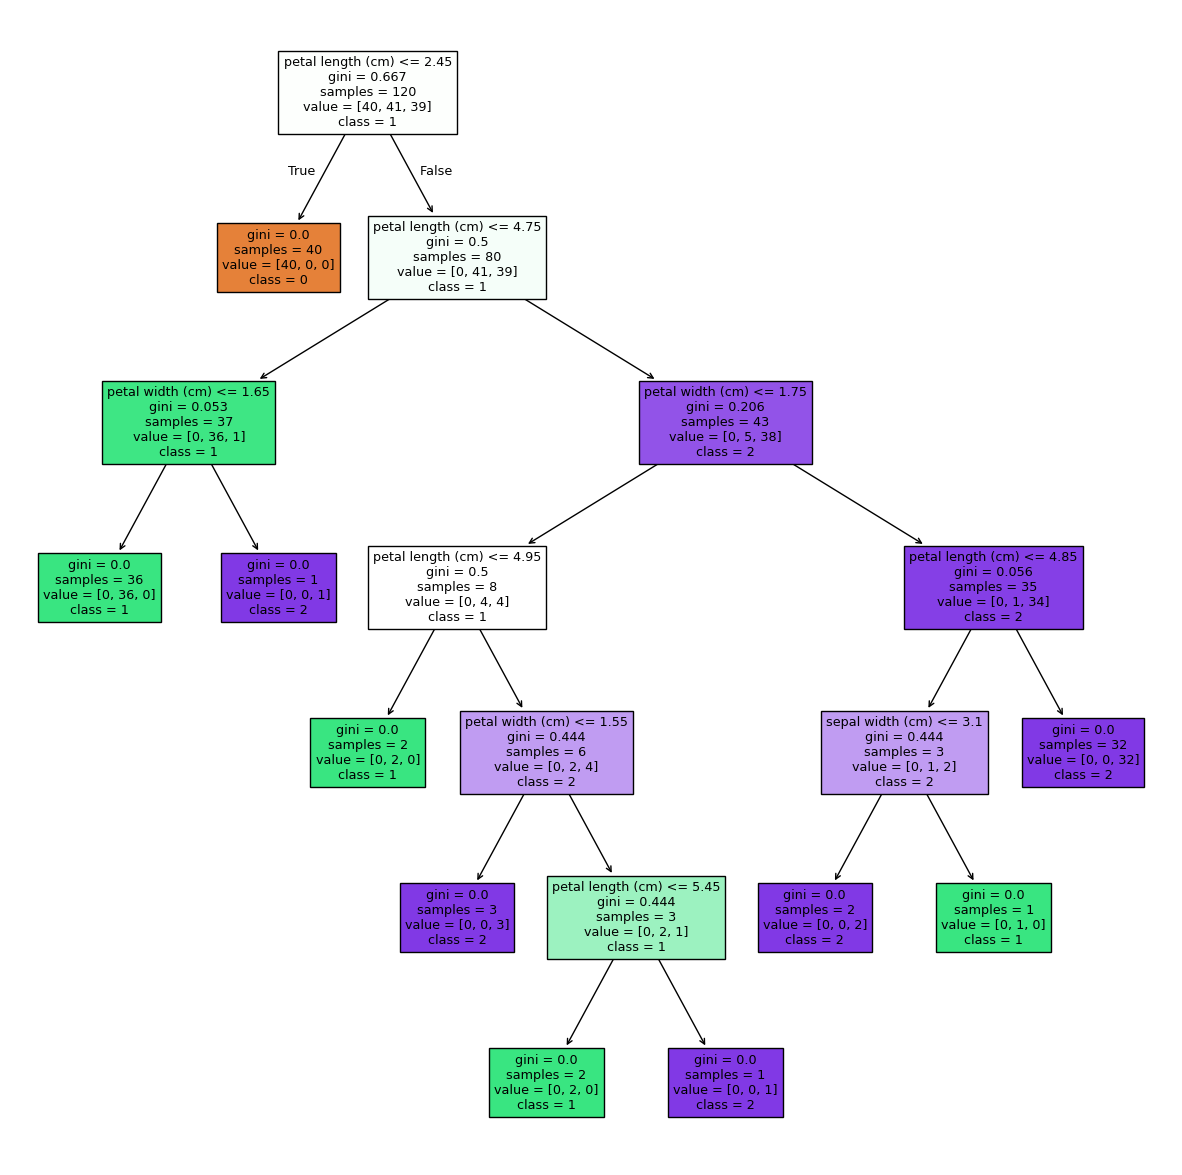

In [36]:
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize=(15, 15))

tree.plot_tree(
    model, feature_names=list(X_train.columns), class_names=["0", "1", "2"], filled=True
)

plt.show()

In [92]:
# normalization scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_norm = scaler.transform(X_train)
X_train_norm = pd.DataFrame(X_train_norm, index=X_train.index, columns=num_variables)

X_test_norm = scaler.transform(X_test)
X_test_norm = pd.DataFrame(X_test_norm, index=X_test.index, columns=num_variables)

X_train_norm.head()

,age,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
32140,-0.184978,-0.679144,-0.738824,-1.043982,-0.516863,0.796144,-0.439289,0.763253,-0.922330,1.432698,-0.173323,0.868251,0.187119,-0.340099,-1.287543,-1.252000,-1.257623,-1.385809,-1.009614
38791,2.551921,0.549525,-0.738824,-1.502403,-0.516863,0.796144,1.762802,-1.310182,1.176781,0.725655,3.401828,-0.569087,0.187119,-0.340099,-2.345618,-1.686068,2.441139,-1.737106,-2.173948
29839,-0.575963,-0.679144,-0.738824,-0.127139,-0.516863,0.796144,-0.439289,0.763253,2.436248,-1.395476,0.562048,-0.209752,0.187119,-0.340099,-1.287543,-0.928228,-1.464386,-1.331854,-1.009614
6201,0.987979,-1.088700,-0.738824,-0.585561,-0.516863,-1.055652,-0.439289,-1.310182,-0.922330,-0.688433,0.468171,-0.569087,0.187119,-0.340099,0.630218,0.706643,0.993798,0.692650,0.301688
25293,0.108261,0.139969,0.689831,0.331282,1.933315,0.796144,-0.439289,0.763253,1.176781,-0.688433,-0.740496,-0.209752,-5.355859,1.701126,-0.163338,-0.705857,-0.292728,0.279773,0.370178


In [93]:
# min-max scaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scal = scaler.transform(X_train)
X_train_scal = pd.DataFrame(X_train_scal, index=X_train.index, columns=num_variables)

X_test_scal = scaler.transform(X_test)
X_test_scal = pd.DataFrame(X_test_scal, index=X_test.index, columns=num_variables)

X_train_scal.head()

,age,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
32140,0.269231,0.181818,0.000000,0.142857,0.0,0.5,0.0,1.0,0.000000,1.00,0.056275,0.095238,1.000000,0.000000,0.333333,0.269680,0.222222,0.153933,0.512287
38791,0.628205,0.454545,0.000000,0.000000,0.0,0.5,0.5,0.0,0.555556,0.75,0.297754,0.000000,1.000000,0.000000,0.000000,0.174591,1.000000,0.018136,0.203781
29839,0.217949,0.181818,0.000000,0.428571,0.0,0.5,0.0,1.0,0.888889,0.00,0.105945,0.023810,1.000000,0.000000,0.333333,0.340608,0.178744,0.174790,0.512287
6201,0.423077,0.090909,0.000000,0.285714,0.0,0.0,0.0,0.0,0.000000,0.25,0.099604,0.000000,1.000000,0.000000,0.937500,0.698753,0.695652,0.957379,0.859735
25293,0.307692,0.363636,0.333333,0.571429,0.5,0.5,0.0,1.0,0.555556,0.25,0.017966,0.023810,0.004004,0.142857,0.687500,0.389322,0.425121,0.797778,0.877883


In [94]:
# feature selection for selecting most-relevant features to use for building ML model

from sklearn.feature_selection import f_classif, SelectKBest

# With a value of k = 16 we implicitly mean that we want to remove 4 features from the 20-column dataset
selection_model = SelectKBest(f_classif, k=16)
selection_model.fit(X_train_scal, y_train)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(
    selection_model.transform(X_train), columns=X_train.columns.values[ix]
)
X_test_sel = pd.DataFrame(
    selection_model.transform(X_test), columns=X_test.columns.values[ix]
)

X_train_sel.head()

,age,job_n,marital_n,education_n,default_n,contact_n,month_n,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,38.0,2.0,0.0,1.0,0.0,1.0,0.0,213.0,5.0,999.0,0.0,-1.8,92.893,-46.2,1.313,5099.1
1,66.0,5.0,0.0,0.0,0.0,0.0,5.0,1127.0,1.0,999.0,0.0,-3.4,92.649,-30.1,0.714,5017.5
2,34.0,2.0,0.0,3.0,0.0,1.0,8.0,401.0,2.0,999.0,0.0,-1.8,93.075,-47.1,1.405,5099.1
3,50.0,1.0,0.0,2.0,0.0,0.0,0.0,377.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
4,41.0,4.0,1.0,4.0,1.0,1.0,5.0,68.0,2.0,4.0,1.0,-0.1,93.200,-42.0,4.153,5195.8


In [99]:
X_train_sel["poutcome_n"] = list(y_train)
X_test_sel["poutcome_n"] = list(y_test)

In [100]:
X_train_sel.to_csv(
    "../data/interim/clean_banking_marketing_campaign.csv",
    index=False,
)
X_test_sel.to_csv("../data/interim/clean_banking_marketing_campaign.csv", index=False)

In [101]:
import pandas as pd

train_data = pd.read_csv("../data/interim/clean_banking_marketing_campaign.csv")
test_data = pd.read_csv("../data/interim/clean_banking_marketing_campaign.csv")

train_data.head()

,age,job_n,marital_n,education_n,default_n,contact_n,month_n,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,price,poutcome_n
0,50.0,3.0,0.0,0.0,0.0,1.0,0.0,197.0,2.0,999.0,0.0,-1.8,92.893,-46.2,1.299,5099.1,0,0
1,30.0,6.0,1.0,1.0,0.0,1.0,0.0,402.0,2.0,999.0,0.0,-1.8,92.893,-46.2,1.334,5099.1,0,0
2,50.0,3.0,0.0,0.0,1.0,0.0,0.0,100.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.856,5191.0,0,0
3,59.0,1.0,0.0,1.0,0.0,1.0,8.0,542.0,3.0,999.0,1.0,-1.8,93.075,-47.1,1.453,5099.1,1,1
4,41.0,4.0,0.0,4.0,0.0,1.0,8.0,466.0,5.0,999.0,1.0,-1.8,93.075,-47.1,1.423,5099.1,1,1


In [116]:
X_train = train_data.drop(["poutcome_n"], axis=1)
y_train = train_data["poutcome_n"]
X_test = test_data.drop(["poutcome_n"], axis=1)
y_test = test_data["poutcome_n"]

In [117]:
from sklearn.linear_model import LogisticRegression

model_using_plain_default_hyperparams = LogisticRegression()
model_using_plain_default_hyperparams.fit(X_train, y_train)

c:\Users\Nick\git\logistic-regression-project-tutorial-NWinocur\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [118]:
y_pred = model_using_plain_default_hyperparams.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(8092,))

#### Accuracy score without hyperparameter optimization

In [119]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8947108255066732

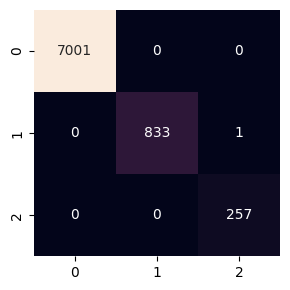

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

bank_marketing_co_matr = confusion_matrix(y_test, y_pred)

# Let's draw this matrix to make it more visual
cm_df = pd.DataFrame(bank_marketing_co_matr)

plt.figure(figsize=(3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.show()

In [127]:
model_using_higher_max_iterations = LogisticRegression(max_iter=100000)
model_using_higher_max_iterations.fit(X_train, y_train)
y_pred = model_using_higher_max_iterations.predict(X_test)
y_pred
accuracy_score(y_test, y_pred)

0.999876421156698

Three-nines accuracy in less than 25 seconds of processing time made this better in terms of both accuracy and computational intensity vs. just jumping straight to trying hyperparameter tuning on an otherwise-default model.

#### Hyperparameter optimizing
##### Grid search

In [ ]:
from sklearn.model_selection import GridSearchCV

# We define the parameters that we want to adjust by hand
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"],
}

# We initialize the grid
grid = GridSearchCV(
    model_using_plain_default_hyperparams, hyperparams, scoring="accuracy", cv=5
)
grid

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [122]:
def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn

grid.fit(X_train, y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'C': 0.001, 'penalty': None, 'solver': 'newton-cg'}


In [123]:
model_grid = LogisticRegression(penalty="l1", C=10, solver="liblinear")
model_grid.fit(X_train, y_train)
y_pred = model_grid.predict(X_test)

grid_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy

0.9962926347009392

Two-nines accuracy is substantially better than sub-90, and is better than random search finds in cells below.  But needing to take about 3 minutes 43 seconds to get it seems not worthwhile to me vs. just upping the max iterations on the plain model enough to get three nines in less time.

##### Random search hyperparameter optimization-hunting

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

# We define the parameters we want to adjust
hyperparams = {
    "C": np.logspace(-4, 4, 20),
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"],
}

# We initialize the random search
random_search = RandomizedSearchCV(
    model_using_plain_default_hyperparams,
    hyperparams,
    n_iter=100,
    scoring="accuracy",
    cv=5,
    random_state=42,
)
random_search

RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=100,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'penalty': ['l1', 'l2', 'elasticnet',
                                                    None],
                                        'solver': ['newton-cg', 'lbfgs',
                                                   'liblinear', 'sag',
                                                   'saga']},
                   random_state=42, scoring='accuracy')

In [125]:
random_search.fit(X_train, y_train)

print(f"Best hyperparameters: {random_search.best_params_}")

c:\Users\Nick\git\logistic-regression-project-tutorial-NWinocur\.venv\Lib\site-packages\scipy\optimize\_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
c:\Users\Nick\git\logistic-regression-project-tutorial-NWinocur\.venv\Lib\site-packages\sklearn\utils\optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(


Best hyperparameters: {'solver': 'newton-cg', 'penalty': 'l2', 'C': np.float64(10000.0)}


In [126]:
model_random_search = LogisticRegression(penalty="l2", C=29.7635, solver="lbfgs")
model_random_search.fit(X_train, y_train)
y_pred = model_random_search.predict(X_test)

random_search_accuracy = accuracy_score(y_test, y_pred)
random_search_accuracy

0.8952051408798813

89.52% accuracy is better than 89.47%, barely, but still not as good as either upping max iteration on an otherwise-default model, or the hyperparameters found by grid search above.